In [1]:
%matplotlib inline
import cmlreaders as cml
from cmlreaders import CMLReader, get_data_index
import matplotlib.pyplot as plt 
import matplotlib as mp
from matplotlib.ticker import StrMethodFormatter
from matplotlib.lines import Line2D

import scipy 
from scipy import stats 

import pandas as pd 
import numpy as np
import os 
import sys

import pybeh_pd as pb
import pybeh_pd_min as pb_min
import seaborn as sns
import importlib

from brokenaxes import brokenaxes
import seaborn as sns

import pickle

In [2]:
# Loftus-Masson (1994) adjustment for between-subject variability.
def loftus_masson(df, sub_cols, cond_col, value_col, within_cols=[]):
    if not isinstance(sub_cols, list):
        sub_cols = [sub_cols]
    if not isinstance(within_cols, list):
        within_cols = [within_cols]
    df = df.copy()
    if len(within_cols) > 0:
        df['M'] = df.groupby(within_cols)[value_col].transform('mean')
    else:
        df['M'] = df[value_col].mean()
    df['M_S'] = df.groupby(sub_cols + within_cols)[value_col].transform('mean')
    df['adj_' + value_col] = (df[value_col] + df['M'] - df['M_S'])
    return df

In [3]:
exp1_data = pd.read_csv('dataframes/KateEtal22_filter_exp1_ffr_evs.csv')

In [4]:
wordpool = exp1_data.query("type=='WORD'").item_name.unique()

In [5]:
exp1_all_data = pd.read_csv('dataframes/exp1_all_evs.csv')
practice_words = exp1_all_data.query("type=='PRACTICE_WORD'").item_name.unique()

# Semantic CRP

## Overall effect

In [18]:
sem_sim_num_df = pd.read_csv('dataframes/exp1_sem_sim_num_df.csv')

In [19]:
sem_sims = pd.pivot_table(sem_sim_num_df, index='item_num_1', columns='item_num_2', 
                          values='similarity', dropna=False)

In [20]:
#removing doughnut because there's no vector
exp1_sem = exp1_data.query('not (item_name == "DOUGHNUT" and type == "WORD")')

In [21]:
exp1_sem = exp1_sem.query('session>=5')

In [181]:
pb_sem_crp = exp1_sem.groupby(['subject', 'session']).apply(
    pb.pd_sem_crp, list_index=['subject', 'session'], rec_type='FFR_REC_WORD',
    itemno_column='item_num_new', sem_sims=sem_sims).reset_index()

In [182]:
pb_sem_crp_sub = pb_sem_crp.groupby(['subject','sem_bin']).agg({'prob':np.nanmean, 'sem_bin_mean':np.nanmean}).reset_index()

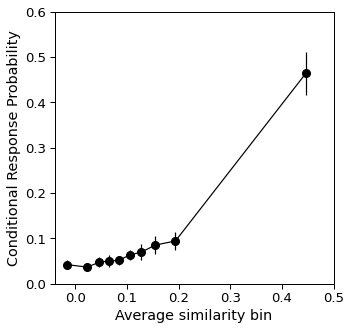

In [81]:
def std_ddof(a):
    std = np.std(a, ddof=1)
    return std

with sns.plotting_context(context='paper', font_scale=1.5, 
                       ):
    fig = plt.figure(figsize=(5, 5))
    x = pb_sem_crp_sub.groupby('sem_bin').agg({'sem_bin_mean':np.nanmean})['sem_bin_mean']
    y = pb_sem_crp_sub.groupby('sem_bin').agg(mean_sem=('prob', 'mean'))['mean_sem'].to_numpy()
    std = pb_sem_crp_sub.groupby('sem_bin').agg(std=('prob', std_ddof))['std'].to_numpy()
    count = pb_sem_crp_sub.groupby('sem_bin').agg(count=('subject', 'nunique'))['count'].to_numpy()
    yerr = 1.96 * (std / (count ** 0.5))
    
    plt.errorbar(x, y, yerr = yerr, color='k', marker='o', markersize=8)
    plt.xlabel('Average similarity bin')
    plt.ylabel('Conditional Response Probability')
    plt.ylim(0,0.6)
    plt.xlim(-.04, 0.5)
    
    #plt.savefig('figures/exp1_semcrp.pdf')

## Change in effect across sessions

In [22]:
exp1_dist_fact = exp1_sem.groupby(['subject', 'session']).apply(
    pb.pd_dist_fact, list_index=['subject', 'session'], rec_type='FFR_REC_WORD',
    itemno_column='item_num_new', dist_mat=sem_sims, is_similarity=True).reset_index().rename(columns={0:'prob'})

In [23]:
exp1_dist_fact.to_csv('dataframes/exp1_sem.csv', index=False)

In [24]:
loftus_masson_sem=loftus_masson(exp1_dist_fact, 'subject', 'session', 'prob')

# Lag-CRP 

## Overall effect

In [25]:
# the most recent encoding phase occurs prior to retrieval - adjusting for this to run script. 
word_evs = exp1_data.query('type == "WORD"')
ffr_rec_evs = exp1_data.query('session >= 5 and type == "FFR_REC_WORD"')
word_evs['session'] = word_evs['session'] + 1
word_evs = word_evs[word_evs['session']<10]
ffr_evs = pd.concat([word_evs, ffr_rec_evs])

/usr/global/miniconda/py310_23.1.0-1/envs/workshop/lib/python3.7/site-packages/ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after removing the cwd from sys.path.


In [7]:
pb_lag_crp = ffr_evs.groupby(['subject','session']).apply(pb.pd_crp, list_index=['subject', 'session'], rec_type='FFR_REC_WORD',
                                itemno_column='item_num_new', lag_num=10).reset_index()

In [8]:
pb_lag_crp_sub = pb_lag_crp.groupby(['subject','lag']).agg({'prob':'mean'}).reset_index()

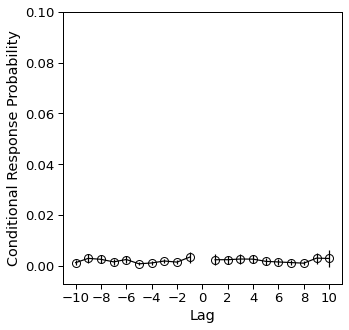

In [9]:
def std_ddof(a):
    std = np.std(a, ddof=1)
    return std

with sns.plotting_context(context='paper', font_scale=1.5): 
    fig = plt.figure(figsize=(5, 5))
    x = np.arange(-10,11,dtype=int)
    y = pb_lag_crp_sub.groupby('lag').agg({'prob':'mean'})['prob'].to_numpy()
    std = pb_lag_crp_sub.groupby('lag').agg(std=('prob',std_ddof))['std'].to_numpy()
    count = pb_lag_crp_sub.groupby('lag').agg(count=('prob','count'))['count'].to_numpy()
    yerr = 1.96 * (std / (count ** 0.5))

    plt.errorbar(x, y, yerr=yerr, color='k', marker='o', markersize=8, fillstyle='none');
    plt.ylim(0,0.5)
    plt.xlabel('Lag')
    plt.ylabel('Conditional Response Probability')
    plt.xticks(np.arange(-10,11,2))
    #plt.savefig('figures/exp1_temp.pdf')

## Change in effect across sessions

In [26]:
exp1_temp_fact = ffr_evs.groupby(['subject', 'session']).apply(
    pb.pd_temp_fact, list_index=['subject', 'session'], pres_type="WORD", rec_type='FFR_REC_WORD',
    itemno_column='item_num_new').reset_index().rename(columns={0:'prob'})

In [27]:
exp1_temp_fact = exp1_temp_fact.dropna(axis='rows')

In [28]:
exp1_temp_fact.to_csv('dataframes/exp1_temp.csv', index=False)

In [90]:
loftus_masson_temp=loftus_masson(exp1_temp_fact, 'subject', 'session', 'prob')

## plotting change in semantic and temporal clustering effects on the same graph

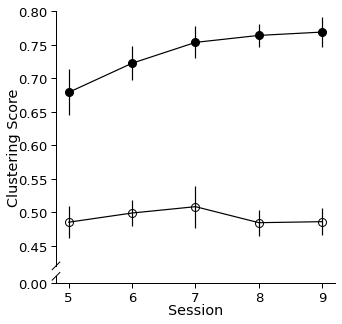

In [92]:
def std_ddof(a):
    std = np.std(a, ddof=1)
    return std

with sns.plotting_context(context='paper', font_scale=1.5, 
#                           rc={'axes.labelsize': 100}
                         ):
    fig = plt.figure(figsize=(5, 5))
    bax = brokenaxes(ylims=((0, 0.01), (0.42
                                        , 0.80)), hspace=.08)
    x = np.arange(5,10,dtype=int)    
    y_sem = loftus_masson_sem.groupby('session').agg(sem_prob=('adj_prob','mean'))['sem_prob'].to_numpy()
    std_sem = loftus_masson_sem.groupby('session').agg(std=('adj_prob',std_ddof))['std'].to_numpy()
    count_sem = loftus_masson_sem.groupby('session').agg(count=('adj_prob', 'count'))['count'].to_numpy()
    yerr_sem = 1.96 * (std_sem / (count_sem ** 0.5))
    bax.errorbar(x, y_sem, yerr = yerr_sem, color='k', marker='o', markersize=8, label='Semantic')
    
    y_temp = loftus_masson_temp.groupby('session').agg(sem_prob=('adj_prob','mean'))['sem_prob'].to_numpy()
    std_temp = loftus_masson_temp.groupby('session').agg(std=('adj_prob',std_ddof))['std'].to_numpy()
    count_temp = loftus_masson_temp.groupby('session').agg(count=('adj_prob', 'count'))['count'].to_numpy()
    yerr_temp = 1.96 * (std_temp / (count_temp ** 0.5))
    bax.errorbar(x, y_temp, yerr = yerr_temp, color='k', marker='o', markersize=8, fillstyle='none', label='Temporal')
    
    

    #bax.legend(loc=3)
    
    bax.set_xticks(np.arange(5,10,1,dtype=int))
    bax.set_xlabel('Session')
    bax.set_ylabel('Clustering Score')
    #plt.savefig('figures/exp1_temp_and_sem.pdf')

# Subjective CRP

## Overall effect

In [29]:
subj_evs = exp1_data.query('type == "FFR_REC_WORD"')

In [30]:
# give item numbers to recalled items that will serve as presetation items
item_col = 'item_name'
item_num_col = 'ffr_item_num'
item_num_df = subj_evs.drop_duplicates(subset=item_col, ignore_index=True
                                    )[item_col].reset_index().rename(columns={'index': item_num_col})
item_num_df[item_num_col] = item_num_df[item_num_col] + 1
subj_evs = subj_evs.merge(item_num_df, how='left')

In [31]:
# replace the item number for practice words by -999 so that they are not considered in the analyses
subj_evs.loc[subj_evs['item_name'].isin(practice_words), 'ffr_item_num'] = -999

In [32]:
ffr_pres_evs = subj_evs.copy()
ffr_pres_evs['type'] = "FFR_WORD"
ffr_pres_evs['session'] = ffr_pres_evs['session'] + 1
ffr_pres_evs = ffr_pres_evs.query('session!=10')

In [33]:
num_recs = ffr_pres_evs.groupby(['subject','session']).agg(num_recs=('item_name','count')).reset_index()

In [34]:
ffr_pres_evs_overall = ffr_pres_evs.merge(num_recs, on=['subject','session'], how='left')

In [35]:
# only keep sessions with more than 10 recalls serving as presentation events
ffr_pres_evs_overall = ffr_pres_evs_overall[ffr_pres_evs_overall['num_recs']>10]

In [36]:
# sessions 1-4 have no free recall task, so no presenation evs for session 5
ffr_rec_evs = subj_evs.query('session != 5') 

In [37]:
ffr_subj_org_evs_overall = pd.concat([ffr_pres_evs_overall, ffr_rec_evs])

In [102]:
pb_min_crp = ffr_subj_org_evs_overall.groupby(['subject', 'session']).apply(pb_min.pd_min_crp_subj, lag_num=10,list_index=['subject', 'session'],
                                                   pres_type='FFR_WORD',
                                          rec_type='FFR_REC_WORD', 
                                          itemno_column='ffr_item_num', 
                                           max_n_reps=4).reset_index()

In [103]:
pb_min_crp = pb_min_crp.groupby(['subject', 'lag']).agg({'prob':'mean'}).reset_index()

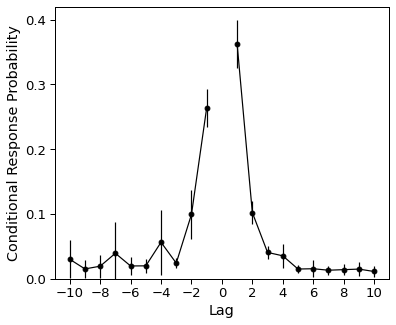

In [104]:
def std_ddof(a):
    std = np.std(a, ddof=1)
    return std

with sns.plotting_context(context='paper', font_scale=1.5): 
    fig = plt.figure(figsize=(6, 5))
    x = np.arange(-10,11,dtype=int)
    y = pb_min_crp.groupby('lag').agg({'prob':'mean'})['prob'].to_numpy()
    std = pb_min_crp.groupby('lag').agg(std=('prob',std_ddof))['std'].to_numpy()
    count = pb_min_crp.groupby('lag').agg(count=('prob','count'))['count'].to_numpy()
    yerr = 1.96 * (std / (count ** 0.5))

    plt.errorbar(x, y, yerr=yerr, color='k', marker='o');
    plt.ylim(0,0.42)
    plt.yticks(np.arange(0,0.5,0.1))
    plt.xlabel('Lag')
    plt.ylabel('Conditional Response Probability')
    plt.xticks(np.arange(-10,11,2))
    #plt.savefig('figures/exp1_subj.pdf')

## Change in the effect across sessions

In [38]:
ffr_subj_org_evs = pd.concat([ffr_pres_evs, ffr_rec_evs])

In [39]:
exp1_subj_fact = ffr_subj_org_evs.groupby(['subject', 'session']).apply(
    pb.pd_min_temp_fact, pres_type="FFR_WORD", rec_type='FFR_REC_WORD', list_index=['subject', 'session'],
    itemno_column='ffr_item_num', max_n_reps=4).to_frame('prob').reset_index()

In [40]:
exp1_subj_fact = exp1_subj_fact.dropna(axis='rows')

In [41]:
exp1_subj_fact.to_csv('dataframes/exp1_subj.csv', index=False)

In [108]:
loftus_masson_subj=loftus_masson(exp1_subj_fact, 'subject', 'session', 'prob')

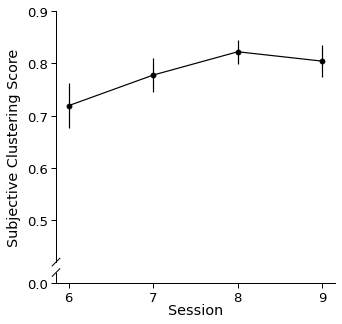

In [109]:
def std_ddof(a):
    std = np.std(a, ddof=1)
    return std

with sns.plotting_context(context='paper', font_scale=1.5, 
#                           rc={'axes.labelsize': 100}
                         ):
    fig = plt.figure(figsize=(5, 5))
    bax = brokenaxes(ylims=((0, 0.02), (0.42, 0.9)), hspace=.08)
    x = np.arange(6,10,dtype=int)
    y = loftus_masson_subj.groupby('session').agg(subj_prob=('adj_prob','mean'))['subj_prob'].to_numpy()
    std = loftus_masson_subj.groupby('session').agg(std=('adj_prob',std_ddof))['std'].to_numpy()
    count = loftus_masson_subj.groupby('session').agg(count=('adj_prob', 'count'))['count'].to_numpy()

    yerr = 1.96 * (std / (count ** 0.5))
    bax.errorbar(x,y, yerr = yerr, color='k', marker='o' )
    #bax.errorbar(x,y, yerr = yerr, color='k', marker='o' )
    #bax.ylim(0,0.40)
    bax.set_xticks(np.arange(6,10,1,dtype=int))
    bax.set_xlabel('Session')
    bax.set_ylabel('Subjective Clustering Score')
    #plt.savefig('figures/exp1_subjtrend.pdf')

## Subjective CRP at session S based on S-1 and S-2

In [110]:
fr_data = exp1_data.query('type=="FFR_REC_WORD"')

In [111]:
subjects = fr_data.subject.unique()

In [160]:
for sub in subjects:
    sub_df = fr_data[fr_data['subject']==sub]
    recs_per_sess = []
    for sess, sess_df in sub_df.groupby('session'):
        sess_recs = sess_df.item_name.to_list()
        recs_per_sess.append(sess_recs)
    with open(f'recalls_data/{sub}_recs_per_sess.pkl', 'wb') as f:
        pickle.dump(recs_per_sess, f)


In [161]:
# create a dictionary for each subject where the sess num is paired
# with its list of recalls, and their serial positions.

for sub in subjects:
    recs_per_sess_dict = {}
    with open(f'recalls_data/{sub}_recs_per_sess.pkl', 'rb') as f:
        recs_per_sess_lst = pickle.load(f)
    
    sub_data = fr_data[fr_data['subject']==sub]
    sessions = sub_data.session.unique()
    
    for s, sess in enumerate(sessions):
        recs = np.array(recs_per_sess_lst[s], dtype=object)  # Use dtype=object if elements are strings

        # Create serial positions
        serialpos = np.arange(1, (len(recs) + 1), dtype=int)

        # Create a boolean mask: True if NOT in practice_words
        mask = np.isin(recs, list(practice_words), invert=True)

        # Apply the mask to filter recs and serialpos
        recs_no_practice = recs[mask]
        serialpos_no_practice = serialpos[mask]

        # Update dictionary
        recs_per_sess_dict[sess] = [recs_no_practice, serialpos_no_practice]
    
    with open(f'recalls_data/{sub}_recs_and_sp_per_sess_dict.pkl', 'wb') as f:
        pickle.dump(recs_per_sess_dict, f)

In [162]:
min(list(recs_per_sess_dict.keys()))

5

In [163]:
# the list of possible bins
from itertools import product

# Define the arrays (excluding 0)
lags = list(range(-4, 0)) + list(range(1, 5))  # [-4, -3, -2, -1, 1, 2, 3, 4]

    

In [164]:
def get_min_trans(serialpos, rec):
    # positive values come first so argmin will select positive values
    # See Howard and Kahana 2005 for method -- always select positive in case of tie
    pt = [sp - r for sp in serialpos for r in rec if len(serialpos)>0 and len(rec)>0]
    pt.sort(reverse=True)
    if len(pt)>0:
        return pt[np.argmin(np.abs(pt))]
    else:
        return np.nan

In [165]:
# Lag-CRP with categories of far and close in s-2

In [166]:
def lag_crp_2d_cat(sub, lags):

    # dict with all bins, to update as we loop over recalls
    actual_lag_dict_close = {l: 0 for l in lags}
    actual_lag_dict_far = {l: 0 for l in lags}  

    poss_lag_dict_close = {l: 0 for l in lags}
    poss_lag_dict_far = {l: 0 for l in lags}

    with open(f'recalls_data/{sub}_recs_and_sp_per_sess_dict.pkl', 'rb') as f:
        recs_sp_dict = pickle.load(f)
    
    sessions = list(recs_sp_dict.keys())
    sessions_gr6 = [s for s in sessions if s>6]

    for s in sessions_gr6:

        # reset counters here for a version of the code where you get prob values at the session-level

        sess_data = recs_sp_dict[s]
        recs = sess_data[0]

        if (s-1 in sessions) and (s-2 in sessions): # check that these sessions exist
            # get recalls and sps from sess s-1
            sess_1back_data = recs_sp_dict[s-1]
            recs_1back = sess_1back_data[0]
            sps_1back = sess_1back_data[1]

            # get recalls and sps from sess s-2
            sess_2back_data = recs_sp_dict[s-2]
            recs_2back = sess_2back_data[0]
            sps_2back = sess_2back_data[1]

            # get the list of serial positions of possible recalls at s-1 and s-2
            # possible recalls are common recalls in s-1 and s-2
            common_recs_1b_2b = np.intersect1d(recs_1back, recs_2back)

            poss_sp_dict = {}
            for c_rec in common_recs_1b_2b:
                sp_1back = sps_1back[np.where(recs_1back==c_rec)[0]]
                # sp_2back = sps_2back[np.where(recs_2back==c_rec)[0]]
                poss_sp_dict.update({c_rec:sp_1back})
                
            # sets to keep track of the sps of already recalled words
            seen = set()
            # seen_1back = set()
            # seen_2back = set()

            for r in range(len(recs) - 1):
                this_rec, next_rec = recs[r], recs[r + 1]
                seen.add(this_rec)
                
                
                if {this_rec, next_rec}.issubset(set(recs_1back)) and {this_rec, next_rec}.issubset(set(recs_2back)):
                    # Get serial positions in s-1 and s-2 for this recall pair
                    sp_this_rec_1back = sps_1back[np.where(recs_1back == this_rec)[0]]
                    sp_next_rec_1back = sps_1back[np.where(recs_1back == next_rec)[0]]
                    sp_this_rec_2back = sps_2back[np.where(recs_2back == this_rec)[0]]
                    sp_next_rec_2back = sps_2back[np.where(recs_2back == next_rec)[0]]

                    # Determine lag bins
                    actual_1back = get_min_trans(sp_next_rec_1back, sp_this_rec_1back)
                    actual_2back = get_min_trans(sp_next_rec_2back, sp_this_rec_2back)

                    incremented_lags = set()
                    
                    if abs(actual_2back) <= 2:
                        if actual_1back in lags:
                            actual_lag_dict_close[actual_1back] += 1
                        
                        for poss in common_recs_1b_2b:
                            if poss in seen:
                                continue  # Skip if already seen

                            poss_1back = get_min_trans(poss_sp_dict[poss], sp_this_rec_1back)

                            if poss_1back in lags and poss_1back not in incremented_lags:
                                poss_lag_dict_close[poss_1back] += 1
                                incremented_lags.add(poss_1back)
                    
                    if abs(actual_2back) > 2:
                        if actual_1back in lags:
                            actual_lag_dict_far[actual_1back] += 1
                            
                            
                        for poss in common_recs_1b_2b:
                            if poss in seen:
                                continue  # Skip if already seen

                            poss_1back = get_min_trans(poss_sp_dict[poss], sp_this_rec_1back)

                            if poss_1back in lags and poss_1back not in incremented_lags:
                                poss_lag_dict_far[poss_1back] += 1
                                incremented_lags.add(poss_1back)




    crps_close = [actual_lag_dict_close[b] / poss_lag_dict_close[b] if poss_lag_dict_close[b] != 0 else np.nan for b in lags]
    crps_far = [actual_lag_dict_far[b] / poss_lag_dict_far[b] if poss_lag_dict_far[b] != 0 else np.nan for b in lags]
    crp_dict_close = {l: (crp if l != 0 else np.nan) for l, crp in zip(lags, crps_close)}     
    crp_dict_far = {l: (crp if l != 0 else np.nan) for l, crp in zip(lags, crps_far)}

    return crp_dict_close, crp_dict_far

In [167]:
lags = list(range(-10, 1)) + list(range(0, 11))
crp_dicts_close = []
crp_dicts_far = []

for sub in subjects:
    crp_dict_close, crp_dict_far = lag_crp_2d_cat(sub, lags)
    crp_dicts_close.append(crp_dict_close)
    crp_dicts_far.append(crp_dict_far)

In [168]:
mean_crp_dict_close = {key: np.nanmean([d[key] for d in crp_dicts_close]) for key in crp_dicts_close[0]}
mean_crp_dict_far = {key: np.nanmean([d[key] for d in crp_dicts_far]) for key in crp_dicts_far[0]}

/usr/global/miniconda/py310_23.1.0-1/envs/workshop/lib/python3.7/site-packages/ipykernel_launcher.py:1: RuntimeWarning: Mean of empty slice
  """Entry point for launching an IPython kernel.
/usr/global/miniconda/py310_23.1.0-1/envs/workshop/lib/python3.7/site-packages/ipykernel_launcher.py:2: RuntimeWarning: Mean of empty slice
  


In [169]:
std_crp_dict_close = {key: np.nanstd([d[key] for d in crp_dicts_close]) for key in crp_dicts_close[0]}
std_crp_dict_far = {key: np.nanstd([d[key] for d in crp_dicts_far]) for key in crp_dicts_far[0]}

/usr/global/miniconda/py310_23.1.0-1/envs/workshop/lib/python3.7/site-packages/numpy/lib/nanfunctions.py:1671: RuntimeWarning: Degrees of freedom <= 0 for slice.
  keepdims=keepdims)


In [170]:
count_dict_close = {
    key: sum(1 for d in crp_dicts_close if not np.isnan(d[key]))
    for key in crp_dicts_close[0]
}
count_dict_far = {
    key: sum(1 for d in crp_dicts_far if not np.isnan(d[key]))
    for key in crp_dicts_close[0]
}

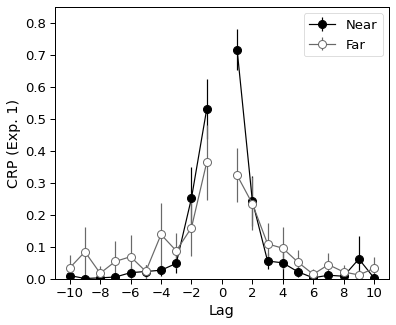

In [123]:
with sns.plotting_context(context='paper', font_scale=1.5, 
#                           rc={'axes.labelsize': 100}
                         ):
    fig = plt.figure(figsize=(6, 5))
    #bax = brokenaxes(ylims=((0, 0.01), (0.42
                                        #, 0.80)), hspace=.08)
    x = list(mean_crp_dict_close.keys()) 
    y_close = list(mean_crp_dict_close.values())
    std_close = np.array(list(std_crp_dict_close.values()))
    count_close = np.array(list(count_dict_close.values()))
    yerr_close = 1.96 * (std_close / (count_close ** 0.5))
    plt.errorbar(x, y_close, yerr = yerr_close, color='k', marker='o', markersize=8, label='Near')
    
    y_far = list(mean_crp_dict_far.values())
    std_far = np.array(list(std_crp_dict_far.values()))
    count_far = np.array(list(count_dict_far.values()))
    yerr_far = 1.96 * (std_far / (count_far ** 0.5))
    plt.errorbar(x, y_far, yerr = yerr_far, color='dimgray', marker='o', markerfacecolor='white', markersize=8,  label='Far')
    
    plt.ylim(0,0.85)
    plt.xticks(np.arange(-10,11,2))
    plt.xlabel('Lag')
    plt.ylabel('CRP (Exp. 1)')
    plt.legend()
    #plt.savefig('figures/exp1_2d_subjcrp.pdf')

## Subjective organization measured by Pair Frequency

In [42]:
fr_data = exp1_data.query('type=="FFR_REC_WORD"')

In [43]:
subjects = fr_data.subject.unique()

In [44]:
exp1_all_data = pd.read_csv('dataframes/exp1_all_evs.csv')
practice_words = exp1_all_data.query("type=='PRACTICE_WORD'").item_name.unique()

In [127]:
for sub in subjects:
    sub_df = fr_data[fr_data['subject']==sub]
    recs_per_sess = []
    for sess, sess_df in sub_df.groupby('session'):
        sess_recs = sess_df.item_name.to_list()
        recs_per_sess.append(sess_recs)
    with open(f'recalls_data/{sub}_recs_per_sess.pkl', 'wb') as f:
        pickle.dump(recs_per_sess, f)


In [45]:
Observed_PF_per_sub = []
common_items_sub = []
num_recs_i_i1_sub = []

for sub in subjects:
    # load the dictionary with a list of lists of words recalled per session
    with open(f'recalls_data/{sub}_recs_per_sess.pkl', 'rb') as f:
        recs_per_sess = pickle.load(f)
    
    num_recs_i_i1_per_sess = []
    Observed_PF_per_sess = [] 
    common_items_per_sess = []
    
    for sess in range(len(recs_per_sess)-1):
        
        # get recalls of current session
        sess_recs = recs_per_sess[sess]
        
        # get set of recalled items in current session, excluding practice words
        sess_recs_not_in_practice = [rec for rec in sess_recs if rec not in practice_words]
        sess_recs_set = set(sess_recs_not_in_practice)
        # get number of recalls on session i
        num_recs_i = len(sess_recs_set)
        
        # create a dictionary with all pairs recalled in sess i, with counter set to 0
        # excluding pairs with at least one practice word
        pairs_dict = {}
        for i in range(len(sess_recs)-1):
            if (sess_recs[i] not in practice_words) and (sess_recs[i+1] not in practice_words):
                pair = (sess_recs[i], sess_recs[i+1])
                pairs_dict.update({pair:0})
            
        # Get recalls of next session
        next_sess_recs = recs_per_sess[sess+1]
        
        # Get recalls of next session, excluding practice words 
        next_sess_recs_not_in_practice = [r for r in next_sess_recs if r not in practice_words]
        next_sess_recs_set = set(next_sess_recs_not_in_practice)
        # get number of recalls in session i+1
        num_recs_i1 = len(next_sess_recs_set)
        # append the number of recalls in trials i and i+1 to the subject-level list
        num_recs_i_i1_per_sess.append([num_recs_i, num_recs_i1])
        
        # count common items recalled in sess i and i+1
        common_words = sess_recs_set & next_sess_recs_set  # Finds common elements, excluding practice words
        num_common_words = len(common_words)
        common_items_per_sess.append(num_common_words)
        
        # increment the pairs that were recalled on both sessions (regardless of order)
        for j in range(len(next_sess_recs)-1):
            next_sess_pair = (next_sess_recs[j], next_sess_recs[j+1])
            for key in list(pairs_dict.keys()):
                if set(next_sess_pair) == set(key):
                    pairs_dict[key] +=1
                    
        Observed_PF = sum(pairs_dict.values())
        Observed_PF_per_sess.append(Observed_PF)
    
    num_recs_i_i1_sub.append(num_recs_i_i1_per_sess)
    common_items_sub.append(common_items_per_sess)
    Observed_PF_per_sub.append(Observed_PF_per_sess)

In [46]:
PF_per_sub = []

for s in range(len(subjects)):
    num_recs = num_recs_i_i1_sub[s]
    c = common_items_sub[s]
    O = Observed_PF_per_sub[s]
    
    PF_per_sess = []
    
    for i in range(len(num_recs)):
        PF_i = O[i] - ((2 * c[i] * (c[i]-1))/(num_recs[i][0] * num_recs[i][1]))
        PF_per_sess.append(PF_i)
        
    PF_per_sub.append(PF_per_sess)
        
                 


In [47]:
# Create a DF with subject, sess, PF
dfs = []
sub_sess_df = fr_data[['subject', 'session']].drop_duplicates(subset=['subject', 'session'])
#sub_sess_df = sub_sess_df[sub_sess_df['session']!=]

for i, (sub, df) in enumerate(sub_sess_df.groupby('subject')):
    sessions = df.session.unique()
    df = df[df['session'] != min(sessions)]
    df["prob"] = PF_per_sub[i]
    dfs.append(df)

/usr/global/miniconda/py310_23.1.0-1/envs/workshop/lib/python3.7/site-packages/ipykernel_launcher.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if __name__ == '__main__':


In [48]:
df_combined = pd.concat(dfs, ignore_index=True)

In [49]:
df_combined.to_csv('dataframes/exp1_subj_PF.csv', index=False)

In [133]:
def loftus_masson(df, sub_cols, cond_col, value_col, within_cols=[]):
    if not isinstance(sub_cols, list):
        sub_cols = [sub_cols]
    if not isinstance(within_cols, list):
        within_cols = [within_cols]
    df = df.copy()
    if len(within_cols) > 0:
        df['M'] = df.groupby(within_cols)[value_col].transform('mean')
    else:
        df['M'] = df[value_col].mean()
    df['M_S'] = df.groupby(sub_cols + within_cols)[value_col].transform('mean')
    df['adj_' + value_col] = (df[value_col] + df['M'] - df['M_S'])
    return df

In [134]:
loftus_masson_subj=loftus_masson(df_combined, 'subject', 'session', 'prob')

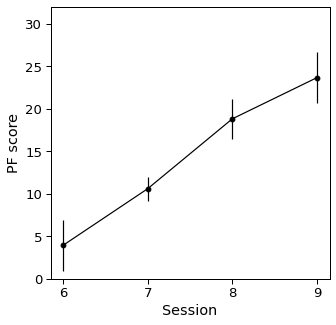

In [135]:
def std_ddof(a):
    std = np.std(a, ddof=1)
    return std

with sns.plotting_context(context='paper', font_scale=1.5, 
#                           rc={'axes.labelsize': 100}
                         ):
    fig = plt.figure(figsize=(5, 5))

    x = np.arange(6,10,dtype=int)
    y = loftus_masson_subj.groupby('session').agg(subj_prob=('adj_prob','mean'))['subj_prob'].to_numpy()
    std = loftus_masson_subj.groupby('session').agg(std=('adj_prob',std_ddof))['std'].to_numpy()
    count = loftus_masson_subj.groupby('session').agg(count=('adj_prob', 'count'))['count'].to_numpy()

    yerr = 1.96 * (std / (count ** 0.5))
    plt.errorbar(x, y, yerr=yerr, color='k', marker='o');
    plt.ylim(0,32)
    #plt.yticks(np.arange(0,0.5,0.1))
    plt.xlabel('Session')
    plt.ylabel('PF score')
    plt.xticks(np.arange(6,10))

    #plt.savefig('figures/exp1_PFtrend.pdf')

# Intrusion analysis

## Intrusion Recency

In [136]:
exp1_data = pd.read_csv('dataframes/KateEtal22_filter_exp1_ffr_evs.csv')

In [137]:
exp1_ffr = exp1_data[(exp1_data['type']=='FFR_REC_WORD') & (exp1_data['session']>= 5)]

In [138]:
# get intrusion events, drop within session repetitions
intrusion_evs = exp1_ffr.query('intrusion==1').drop_duplicates(subset=['subject', 'session', 'item_name'])

In [139]:
# add a column that counts the number of reps for each intrusion across a subject's sessions
intrusion_evs['rep_number'] = intrusion_evs.groupby(['subject','item_name']).cumcount()


In [140]:
reps_per_sub = intrusion_evs[['subject', 'item_name', 'rep_number']]

In [141]:
# only keep the first two occurences of each intrusion
intrusion_evs = intrusion_evs[intrusion_evs['rep_number']<=1]

In [142]:
intrusion_evs.rename(columns={'item_name':'intrusion_name'}, inplace=True)

In [143]:
intrusion_evs = intrusion_evs[['subject','session','intrusion_name','rep_number']]

In [144]:
# dataframe gives the intersession lag for each intrusion
df_lags = intrusion_evs.groupby(['subject','intrusion_name']).agg(lag=('session',np.diff)).reset_index()

In [145]:
# merge intrusion events and their corresponding intersession lag
merge_intr_and_lag = intrusion_evs.merge(df_lags, on=['subject','intrusion_name'])[['subject','session','intrusion_name','lag','rep_number']]

In [146]:
# remove the second occurence of the intrusion from the intrusion events DF (we no longer needed since lags are already computed)
intr_no_within_subj_rep = intrusion_evs.drop_duplicates(subset=['subject', 'intrusion_name'])

In [147]:
# DF with the number of new intrusions per session
intr_count_df = intr_no_within_subj_rep.groupby(['subject','session']).agg(intr_count = ('intrusion_name','count')).reset_index()

In [148]:
# get a DF with the list of sessions per subject
session_df = exp1_ffr.groupby(['subject','session']).agg({'item_name':'count'}).reset_index()[['subject','session']]

In [149]:
# DF with the sessions and intrusions of each subject (to include sessions that have 0 intrusions, which will have an intr count of NaN here)
intr_and_sess_df = session_df.merge(intr_count_df, on=['subject','session'], how='left')

In [150]:
lst_of_sess = []
lst_of_intr_num = []
subjects = []

for l, li in intr_and_sess_df.groupby(['subject']):
    lst_of_sess.append(li['session'].tolist())
    lst_of_intr_num.append(li['intr_count'].tolist())
    subjects.append(l)

In [151]:
poss_lags = np.zeros((len(subjects), 4))
sub_counter = 0
for sess_lst, intr_num_lst in zip(lst_of_sess, lst_of_intr_num):
    # print('sess_lst:', sess_lst)
    # print('intr_num_lst:',intr_num_lst)
    
    poss_lags_sub = np.zeros(4)
    
    for sess, intr in zip(sess_lst, intr_num_lst):
        if sess != 9 and ~np.isnan(intr):
            poss_lags_sub[:9-sess]+=intr
            
    poss_lags[sub_counter,:]+=poss_lags_sub
    sub_counter+=1

In [152]:
new_df_lags = df_lags[df_lags['lag']!=int]

In [153]:
# DF with the number of intrusions per lag, within subject
actual_count_df = new_df_lags.groupby(['subject','lag']).agg(actual_lag_count=('intrusion_name','count')).reset_index()

In [154]:
# DF with the number of possible repetitions across sessions per lag, within subject
poss_count_df = pd.DataFrame(poss_lags)
poss_count_df['subject'] = pd.Series(subjects)
poss_count_df = poss_count_df.rename(columns={0:1, 1:2, 2:3, 3:4})
poss_count_df = poss_count_df.melt(id_vars='subject', value_vars=[1, 2, 3, 4], value_name='poss_lag_count', var_name='lag')

In [155]:
intr_lag_df = actual_count_df.merge(poss_count_df, on=['subject','lag'], how = 'right')

In [156]:
intr_lag_df = intr_lag_df.fillna(0)

In [157]:
intr_lag_df['prob'] = intr_lag_df['actual_lag_count'] / intr_lag_df['poss_lag_count']

In [158]:
intr_lag_df.to_csv('dataframes/exp1_intr_analysis_data.csv', index=False)

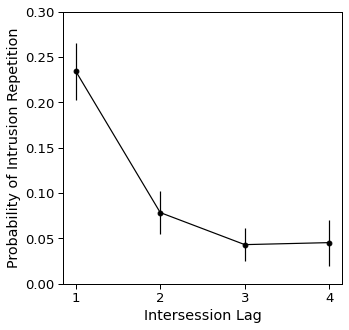

In [159]:
def std_ddof(a):
    std = np.std(a, ddof=1)
    return std

with sns.plotting_context(context='paper', font_scale=1.5): 
    fig = plt.figure(figsize=(5,5))
    x = np.arange(1,5,1,dtype=int)
    y = intr_lag_df.groupby('lag').agg({'prob':'mean'})['prob'].to_numpy()
    std = intr_lag_df.groupby('lag').agg(std=('prob',std_ddof))['std'].to_numpy()
    count = intr_lag_df.groupby('lag').agg(count=('prob','count'))['count'].to_numpy()
    yerr = 1.96 * (std / (count ** 0.5))
    
    plt.errorbar(x, y, yerr=yerr, color='k', marker='o')
    plt.xticks(np.arange(1,5,1,dtype=int))
    plt.ylim(0,0.30)
    plt.xlabel('Intersession Lag')
    plt.ylabel('Probability of Intrusion Repetition')
    plt.savefig('figures/exp1_intrusion.pdf')

